<a href="https://colab.research.google.com/github/25je0784-jpg/Quant_Insider_Competition/blob/main/Introductory_Options'25_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1.1: Binomial Option Pricing Model

## Objective
In this assignment, you will build a Binomial Option Pricing Model from scratch using real market data for the S&P 500 (`^SPX`). You will calculate historical volatility, determine model parameters, and compare your theoretical results with actual market prices.

### 1. Library Installation and Imports
First, we need to install the necessary libraries and import the packages required for data handling and visualization.

In [1]:
# Installing library
!pip install yfinance

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import date
import warnings
import yfinance as yf
import scipy.stats as ss

warnings.filterwarnings("ignore")

### 2. Fetching Market Data
We will fetch historical data for the S&P 500 to calculate the volatility of the underlying asset.

In [2]:
symbol = '^SPX'
end = date.today()
start = end.replace(year = 2023)

tickerData = yf.Ticker(symbol)

# Read historical data
df = tickerData.history(start=start, end=end)
df.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-12-31 00:00:00-05:00,6898.819824,6901.419922,6844.549805,6845.500000,3261830000,0.0,0.0
2026-01-02 00:00:00-05:00,6878.109863,6894.870117,6824.310059,6858.470215,4184120000,0.0,0.0
2026-01-05 00:00:00-05:00,6892.189941,6920.379883,6891.560059,6902.049805,5771930000,0.0,0.0
2026-01-06 00:00:00-05:00,6908.029785,6948.689941,6904.020020,6944.819824,5509680000,0.0,0.0
2026-01-07 00:00:00-05:00,6945.069824,6965.689941,6919.189941,6920.930176,5214480000,0.0,0.0


### 3. Fetching Option Chain Data
To compare our model with the market, we need to fetch the option chain for a specific expiration date.

In [5]:
dfo = yf.Ticker(symbol)

# Get the date of different expiration times
print("Available Expiries:", dfo.options)

# We will select the second available expiration date
dfo_exp = dfo.option_chain(dfo.options[1])

# Display data for call options
dfo_exp.calls.head()

Available Expiries: ('2026-01-08', '2026-01-09', '2026-01-12', '2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16', '2026-01-20', '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-26', '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30', '2026-02-02', '2026-02-03', '2026-02-04', '2026-02-05', '2026-02-06', '2026-02-09', '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13', '2026-02-20', '2026-02-23', '2026-02-27', '2026-03-06', '2026-03-20', '2026-03-31', '2026-04-17', '2026-04-30', '2026-05-15', '2026-05-29', '2026-06-18', '2026-06-30', '2026-07-17', '2026-08-21', '2026-09-18', '2026-09-30', '2026-10-16', '2026-11-20', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-12-15', '2029-12-21', '2030-12-20', '2031-12-19')


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPXW260109C02200000,2026-01-02 18:08:54+00:00,2200.0,4635.89,4706.7,4725.1,0.000000,0.000000,1.0,1,6.968507,True,REGULAR,USD
1,SPXW260109C03000000,2026-01-05 16:29:42+00:00,3000.0,3913.87,3907.3,3925.4,0.000000,0.000000,1.0,2,3.593751,True,REGULAR,USD
2,SPXW260109C04000000,2026-01-07 19:48:24+00:00,4000.0,2946.28,2908.9,2921.5,0.000000,0.000000,446.0,477,3.290895,True,REGULAR,USD
3,SPXW260109C04400000,2025-12-31 15:46:25+00:00,4400.0,2480.31,2508.2,2525.8,0.000000,0.000000,NaN,1,2.250981,True,REGULAR,USD
4,SPXW260109C04600000,2026-01-08 18:46:03+00:00,4600.0,2313.63,2308.4,2322.2,32.339844,1.417612,5.0,2,2.570072,True,REGULAR,USD


### 4. Calculation of Volatility
The factors $u$ (up move) and $d$ (down move) depend on the annual volatility ($\sigma$).

**Task:** Complete the function to calculate annual volatility.
1. Calculate daily log returns.
2. Remove `NaN` values.
3. Calculate the standard deviation of daily returns.
4. Multiply by $\sqrt{252}$ to annualize.

In [7]:
def annual_vol(df):
    """
    Function to calculate annual volatility
    """
    # Step 1: Calculate the daily log returns
    # Hint: np.log(price / price shifted)
    price=df['Close']
    price_shifted=price.shift(1)

    log_return = np.log(price/price_shifted)### YOUR CODE HERE ###

    # Step 2: Remove NaN values
    log_return = log_return.dropna() ### YOUR CODE HERE ###

    # Step 3: Calculate daily standard deviation
    daily_vol =log_return.std() ### YOUR CODE HERE ###

    # Step 4: Annualize the volatility
    vol =daily_vol*np.sqrt(252) ### YOUR CODE HERE ###

    return vol

vol = annual_vol(df)
print(f"Annual Volatility: {vol}")

Annual Volatility: 0.1496309578063213


### 5. Defining Binomial Parameters
We need to define the time to maturity ($T$), the number of steps ($N$), and the factors $u$ and $d$.

**Formula:**
- $u = e^{\sigma\sqrt{t}}$
- $d = e^{-\sigma\sqrt{t}} = 1/u$

In [9]:
# Number of steps
N = 100

# Calculate T: Days left for expiry in years
expiry_date = pd.to_datetime(dfo.options[1]).date()
days_to_expiry = (expiry_date - date.today()).days
T = days_to_expiry / 365

# Length of the step
t = T/N
import math
# Task: Calculate u and d using the formulas above
u = math.exp(vol*math.sqrt(t))### YOUR CODE HERE ###
d = 1/u### YOUR CODE HERE ###

print(f"u: {u}, d: {d}")

u: 1.0007835110132774, d: 0.9992171023956179


### 6. The Binomial Pricing Function
We assume that the stock price changes by either multiplying by $u$ or $d$.
$S(k,m) = S \cdot u^m \cdot d^{k-m}$

The risk-neutral probability $p$ is:
$p = \frac{e^{r\Delta T} - d}{u - d}$

The value of the option at node $(k, m)$ is the discounted expected value:
$C(k,m) = e^{-r\Delta T} [p \cdot C(k+1, m+1) + (1-p) \cdot C(k+1, m)]$

**Task:** Complete the dictionary-based binomial implementation.

In [10]:
def first_binomial_call(S, K, T, r, u, d, N):
    """
    Implementation of binomial pricing model using a dictionary
    """
    dt = T/N
    p =(math.exp(r*dt)-d)/(u-d) ### YOUR CODE HERE: Calculate p ###

    # Dictionary to store the nodes
    C = {}

    # Step 1: Calculate option values at maturity (Step N)
    for m in range(N + 1):
        # Calculate Stock Price at node (N, m)
        S_final = S*math.pow(u,m)*math.pow(d,N-m) ### YOUR CODE HERE ###
        # Calculate Call Price at maturity: max(S - K, 0)
        C[(N, m)] =max(S-K,0) ### YOUR CODE HERE ###

    # Step 2: Work backward through the tree
    for k in range(N - 1, -1, -1):
        for m in range(k + 1):
            # Formula: e^(-r*dt) * (p * C_up + (1-p) * C_down)
            C[(k, m)] =(1/math.exp(r*dt))*(p*C[k+1,m+1]+(1-p)*C[(k+1,m)]) ### YOUR CODE HERE ###

    return C

# Test run for one strike
# Let's use the current close price and a strike price from the table
S_now = df['Close'].iloc[-1]
K_test = dfo_exp.calls['strike'].iloc[0]
r_rate = 0.05 # Assume 5% risk free rate

model_output = first_binomial_call(S_now, K_test, T, r_rate, u, d, N)
print(f"Option Price at Node (0,0): {model_output[(0,0)]}")

Option Price at Node (0,0): 4720.283517310079


### 7. Comparison: Theoretical vs. Actual Market Price
Now we will loop through the market strike prices and compare our model's results with the actual market prices.

In [11]:
# Store results in a dictionary
call_results = {}

for K in dfo_exp.calls['strike']:
    # Use the function to get the tree, then extract node (0,0)
    # We use r = 0.05 (5%) as an estimate for the risk-free rate
    res_tree = first_binomial_call(S = df['Close'].iloc[-1], K = K, T = T, r=0.05, u = u, d =d, N=N)
    call_results[K] = res_tree[(0, 0)]

# Create Theoretical DataFrame
th_call = pd.DataFrame.from_dict(call_results, orient='index')
th_call.rename(columns = {0:"th_call"}, inplace = True)

# Get Actual Call Price data
ac_call = dfo_exp.calls.loc[:, ['strike', 'lastPrice']]
ac_call.set_index('strike', inplace = True)
ac_call.rename(columns = {"lastPrice":"ac_call"}, inplace=True)

# Combine and View
call_comparison = th_call.join(ac_call)
call_comparison.head(10)

,th_call,ac_call
2200.0,4720.283517,4635.89
3000.0,3920.393099,3913.87
4000.0,2920.530076,2946.28
4400.0,2520.584867,2480.31
4600.0,2320.612262,2313.63
5000.0,1920.667053,1922.23
5100.0,1820.680750,1741.38
5200.0,1720.694448,1748.03
5300.0,1620.708146,1618.28
5350.0,1570.714995,1566.67


### 8. Visualization
Finally, let's plot the results to see how well the Binomial model tracks the market prices.

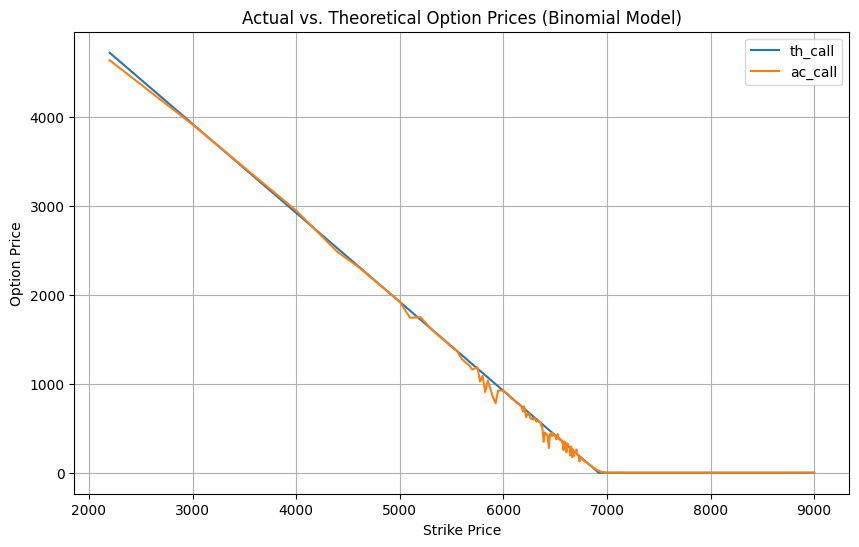

In [12]:
# Plotting the actual and theoretical option prices
call_comparison.plot(figsize=(10, 6))
plt.title("Actual vs. Theoretical Option Prices (Binomial Model)")
plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.grid(True)
plt.show()

# Assignment 1.2: Black-Scholes-Merton Option Pricing


## Objective
The goal of this assignment is to implement the **Black-Scholes-Merton (BSM)** formula to price European vanilla options. You will use real market data to calculate volatility and compare the BSM theoretical prices against actual market premiums.

### 1. Implementation of the Black-Scholes Formula
The Black-Scholes model calculates the price of European Call and Put options using the following formulas:

$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$$
$$d_2 = d_1 - \sigma\sqrt{T}$$

**Call Price:** $C = S \cdot N(d_1) - K e^{-rT} N(d_2)$  
**Put Price:** $P = K e^{-rT} N(-d_2) - S \cdot N(-d_1)$

**Task:** Complete the `euro_vanilla` function.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

def euro_vanilla(S, K, T, r, sigma, option = 'call'):
    """
    To calculate options price with the help of black-scholes model
    """

    # Step 1: Calculate d1 and d2
    # Hint: Use np.log(), np.sqrt(), and norm.cdf() for N(d)
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))### YOUR CODE HERE ###
    d2 = d1 - sigma * np.sqrt(T)### YOUR CODE HERE ###

    if option == 'call':
        # Step 2: Calculate Call Premium
        premium = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)### YOUR CODE HERE ###
    elif option == 'put':
        # Step 3: Calculate Put Premium
        premium = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)### YOUR CODE HERE ###

    return premium

### 2. Time to Maturity (T) Calculation
We need to determine the time remaining until the option expires, expressed in years.

In [14]:
# Identify the selected expiration date from our fetched data
print(f"Option Expiry Date: {dfo.options[1]}")
print(f"Today's Date: {date.today()}")

# Calculate T
# 1. Find the number of days between the expiry date and today
# 2. Divide by 365 to get the value in years
expiry_date = pd.to_datetime(dfo.options[1]).date()
days_to_expiry = (expiry_date - date.today()).days

T = (pd.to_datetime(dfo.options[1]).date() - date.today()).days / 365
print(f"Time to Expiry (T) in years: {T}")

# Defining steps for internal scaling if needed
N = 100
t = T/N

Option Expiry Date: 2026-01-09
Today's Date: 2026-01-08
Time to Expiry (T) in years: 0.0027397260273972603


### 3. Theoretical Call Prices vs. Actual Market Prices
We will now use the historical volatility (`vol`) calculated previously to find the theoretical BSM prices for all strikes in the option chain.


In [16]:
r_val = 0.0123

call = {}
for K in dfo_exp.calls['strike']:
    # Task: Call the euro_vanilla function
    # Use S = df['Close'][len(df)-1]
    call_price = euro_vanilla(S = df['Close'].iloc[-1], K = K, T = T, r = r_val, sigma = vol, option = 'call') ### YOUR CODE HERE ###
    call[K] = call_price

# Convert results to DataFrame
th_call = pd.DataFrame.from_dict(call, orient='index')
th_call.rename(columns = {0:"th_call"}, inplace = True)
th_call.head()

,th_call
2200.0,4721.004312
3000.0,3921.031270
4000.0,2921.064968
4400.0,2521.078447
4600.0,2321.085187


### 4. Comparison and Plotting (Calls)
We will now fetch the actual last trade prices from the market and compare them with our BSM model.


            th_call  ac_call
2200.0  4721.004312  4635.89
3000.0  3921.031270  3913.87
4000.0  2921.064968  2946.28
4400.0  2521.078447  2480.31
4600.0  2321.085187  2313.63
5000.0  1921.098666  1922.23
5100.0  1821.102036  1741.38
5200.0  1721.105406  1748.03
5300.0  1621.108776  1618.28
5350.0  1571.110460  1566.67


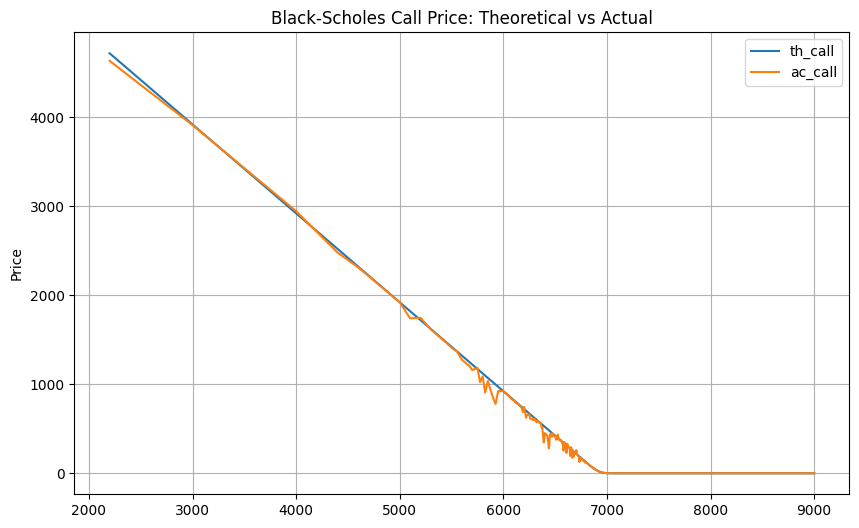

In [17]:
# Step 1: Extract actual call prices
ac_call = dfo_exp.calls.loc[:, ['strike', 'lastPrice']]
ac_call.set_index('strike', inplace = True)
ac_call.rename(columns = {"lastPrice":"ac_call"}, inplace=True)

# Step 2: Combine Theoretical and Actual
call_comp = th_call.copy()
call_comp["ac_call"] = ac_call
print(call_comp.head(10))

# Step 3: Plot the results
call_comp.plot(figsize=(10,6))
plt.title("Black-Scholes Call Price: Theoretical vs Actual")
plt.ylabel("Price")
plt.grid(True)
plt.show()

### 5. Theoretical Put Prices vs. Actual Market Prices
We repeat the process for Put options.

In [18]:
# Assume a slightly different risk free rate as per sample
r_put = 0.0158

put = {}
for K in dfo_exp.puts['strike']:
    # Task: Call the euro_vanilla function for 'put'
    put_price =euro_vanilla(S = df['Close'].iloc[-1], K = K, T = T, r = r_put, sigma = vol, option = 'put') ### YOUR CODE HERE ###
    put[K] = put_price

# Convert results to DataFrame
th_put = pd.DataFrame.from_dict(put, orient='index')
th_put.rename(columns = {0:"th_put"}, inplace = True)
th_put.head()

,th_put
2200.0,0.0
2600.0,0.0
2800.0,0.0
3000.0,0.0
3200.0,0.0


### 6. Comparison and Plotting (Puts)

            th_put  ac_put
7150.0  228.760523  234.58
7160.0  238.759978  228.57
7170.0  248.759495  232.70
7175.0  253.759266  243.71
7180.0  258.759041  301.63
7200.0  278.758162  320.60
7250.0  328.755995  368.48
7270.0  348.755130  388.17
7500.0  578.745174  552.05
7600.0  678.740845  651.95


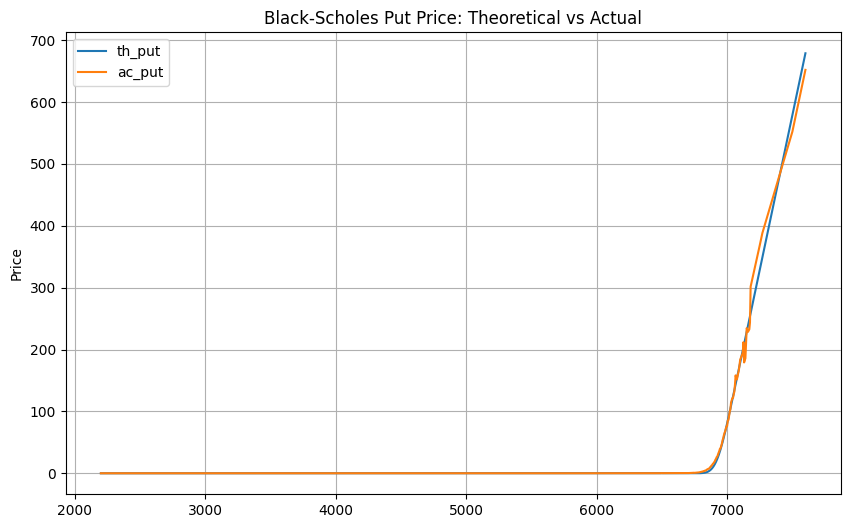

In [19]:
# Step 1: Extract actual put prices
ac_put = dfo_exp.puts.loc[:, ['strike', 'lastPrice']]
ac_put.set_index('strike', inplace = True)
ac_put.rename(columns = {"lastPrice":"ac_put"}, inplace=True)

# Step 2: Combine Theoretical and Actual
put_comp = th_put.copy()
put_comp["ac_put"] = ac_put
print(put_comp.tail(10))

# Step 3: Plot the results
put_comp.plot(figsize=(10,6))
plt.title("Black-Scholes Put Price: Theoretical vs Actual")
plt.ylabel("Price")
plt.grid(True)
plt.show()